# Part 1: The Dataset

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from pathlib import Path

In [2]:
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Colour convention used throughout this notebook:
#   more massive BH = dark red, less massive BH = blue, everything together = black
#   common-envelope channel = orange, stable-mass-transfer channel = teal
C1, C2, CSYS = "#C1272D", "#0B5FA5", "#222222"
C_CE, C_SMT = "#E07B39", "#2A9D8F"


def weighted_median(x, w):
    '''Median of x where each entry carries a statistical weight w (see section 1.4).'''
    order = np.argsort(np.asarray(x))
    x_sorted = np.asarray(x)[order]
    cum_w = np.cumsum(np.asarray(w)[order])
    return x_sorted[np.searchsorted(cum_w, 0.5 * cum_w[-1])]


DATA_PATH = Path("../../../data/COMPAS_Output_wWeights.h5")

print("numpy", np.__version__, "| h5py", h5py.__version__, "| pandas", pd.__version__)

numpy 2.5.1 | h5py 3.16.0 | pandas 3.0.5


In [3]:
# Part 1.3

with h5py.File(DATA_PATH, "r") as f:
    for group in f.keys():
        n_rows = f[group][list(f[group].keys())[0]].shape[0]
        print(f"\nGroup {group}   ({n_rows:,} rows)")
        print("   " + "-" * 66)
        for col in f[group].keys():
            d = f[group][col] 
            print(f"   {col}: {d.shape[0]:,} rows")


Group BSE_Double_Compact_Objects   (2,523,122 rows)
   ------------------------------------------------------------------
   CE_Event_Counter: 2,523,122 rows
   Coalescence_Time: 2,523,122 rows
   Immediate_RLOF>CE: 2,523,122 rows
   MT_Donor_Hist(1): 2,523,122 rows
   MT_Donor_Hist(2): 2,523,122 rows
   Mass(1): 2,523,122 rows
   Mass(2): 2,523,122 rows
   Merges_Hubble_Time: 2,523,122 rows
   Metallicity@ZAMS(1): 2,523,122 rows
   Optimistic_CE: 2,523,122 rows
   SEED: 2,523,122 rows
   Stellar_Type(1): 2,523,122 rows
   Stellar_Type(2): 2,523,122 rows
   Time: 2,523,122 rows
   mixture_weight: 2,523,122 rows

Group BSE_RLOF   (31,878,423 rows)
   ------------------------------------------------------------------
   CEE>MT: 31,878,423 rows
   Eccentricity<MT: 31,878,423 rows
   Eccentricity>MT: 31,878,423 rows
   MT_Event_Counter: 31,878,423 rows
   Mass(1)<MT: 31,878,423 rows
   Mass(1)>MT: 31,878,423 rows
   Mass(2)<MT: 31,878,423 rows
   Mass(2)>MT: 31,878,423 rows
   RLOF(1)>MT:

In [4]:
# Part 1.5

DCO_COLUMNS = [
    "SEED",
    "Mass(1)", "Mass(2)",
    "Stellar_Type(1)", "Stellar_Type(2)",
    "Merges_Hubble_Time", "Coalescence_Time", "Time",
    "Metallicity@ZAMS(1)", "CE_Event_Counter",
    "mixture_weight",
]

with h5py.File(DATA_PATH, "r") as f:
    dco = pd.DataFrame({c: f["BSE_Double_Compact_Objects"][c][()] for c in DCO_COLUMNS})
    n_binaries_simulated = f["BSE_System_Parameters"]["SEED"].shape[0]

dco = dco.rename(columns={
    "Mass(1)": "M1_raw", "Mass(2)": "M2_raw",
    "Stellar_Type(1)": "type1", "Stellar_Type(2)": "type2",
    "Metallicity@ZAMS(1)": "Z",
    "Merges_Hubble_Time": "merges", "Coalescence_Time": "t_coal_Myr",
    "Time": "t_form_Myr", "CE_Event_Counter": "n_CE", "mixture_weight": "w",
})

print(f"binaries simulated in total   : {n_binaries_simulated:,}")
print(f"double compact objects formed : {len(dco):,}"
      f"   ({100 * len(dco) / n_binaries_simulated:.2f}% of all binaries)")
print(f"memory used by our table      : {dco.memory_usage(deep=True).sum() / 1e6:.0f} MB")
dco.head()

binaries simulated in total   : 10,000,000
double compact objects formed : 2,523,122   (25.23% of all binaries)
memory used by our table      : 174 MB


,SEED,M1_raw,M2_raw,type1,type2,merges,t_coal_Myr,t_form_Myr,Z,n_CE,w
0,53,17.013836,16.985069,14,14,0,9.133827e+15,5.466165,0.000212,0,3.921569
1,55,14.970078,12.344720,14,14,1,9.987571e+00,6.276184,0.000353,1,0.003438
2,220,42.781140,33.955125,14,14,0,1.059965e+06,5.630744,0.000157,0,3.921408
3,386,38.245214,37.461885,14,14,0,1.402914e+17,3.821612,0.000218,0,3.921569
4,444,16.172687,15.664367,14,14,0,1.932570e+20,5.652540,0.000432,0,3.921569


# Part 2: Selecting the merging binary black holes

In [5]:
BH, NS = 14, 13   # Hurley et al. (2000) stellar type codes

is_bh1, is_bh2 = dco.type1 == BH, dco.type2 == BH
dco["is_BBH"]  = is_bh1 & is_bh2
dco["is_BHNS"] = is_bh1 ^ is_bh2          # exclusive-or: exactly one is a BH
dco["is_BNS"]  = (dco.type1 == NS) & (dco.type2 == NS)

# order the masses so that m1 >= m2, regardless of which star was born heavier
dco["m1"] = np.maximum(dco.M1_raw, dco.M2_raw)
dco["m2"] = np.minimum(dco.M1_raw, dco.M2_raw)
dco["q"]  = dco.m2 / dco.m1                                       # mass ratio, 0 < q <= 1
dco["Mtot"] = dco.m1 + dco.m2
dco["Mchirp"] = (dco.m1 * dco.m2) ** 0.6 / dco.Mtot ** 0.2        # chirp mass

# --- the census, counted BOTH ways so you can see the difference ----------------
print(f"{'type':10s} {'raw rows':>12s} {'raw %':>8s} {'weighted':>12s} {'weighted %':>11s}")
print("-" * 58)
wtot = dco.w.sum()
for name, mask in [("BH+BH", dco.is_BBH), ("BH+NS", dco.is_BHNS), ("NS+NS", dco.is_BNS)]:
    print(f"{name:10s} {mask.sum():12,} {100*mask.mean():7.2f}% "
          f"{dco.w[mask].sum():12,.0f} {100*dco.w[mask].sum()/wtot:10.2f}%")
print("-" * 58)
print(f"{'TOTAL':10s} {len(dco):12,} {100.0:7.2f}% {wtot:12,.0f} {100.0:10.2f}%")

# --- and now our sample ---------------------------------------------------------
bbh = dco[dco.is_BBH & (dco.merges == 1)].copy()
print(f"\nMerging binary black holes: {len(bbh):,} rows, {bbh.w.sum():,.0f} in weighted units")
print(f"Fraction of all binary black holes that merge within a Hubble time:")
print(f"   counting rows  : {100 * len(bbh) / dco.is_BBH.sum():.1f}%")
print(f"   summing weights: {100 * bbh.w.sum() / dco.w[dco.is_BBH].sum():.1f}%   <-- the real answer")

type           raw rows    raw %     weighted  weighted %
----------------------------------------------------------
BH+BH         2,273,376   90.10%      117,689      78.87%
BH+NS           244,410    9.69%       12,315       8.25%
NS+NS             5,336    0.21%       19,217      12.88%
----------------------------------------------------------
TOTAL         2,523,122  100.00%      149,220     100.00%

Merging binary black holes: 1,640,550 rows, 14,911 in weighted units
Fraction of all binary black holes that merge within a Hubble time:
   counting rows  : 72.2%
   summing weights: 12.7%   <-- the real answer


# Part 3: The 1D black hole mass distribution

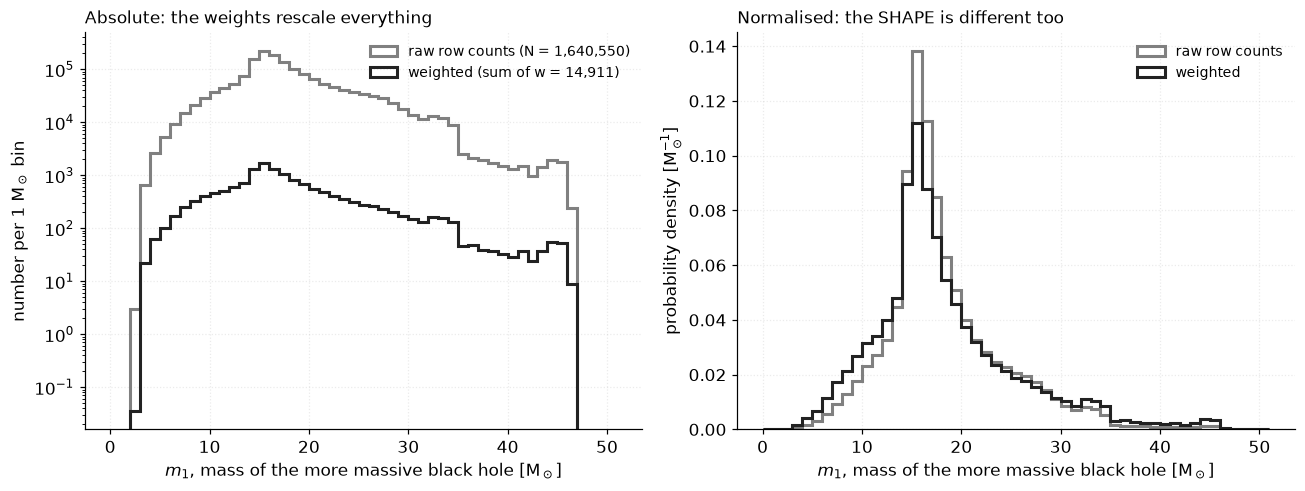

        mass range  counting rows  summing weights   error factor
------------------------------------------------------------------
      m1 < 10 Msun          5.06%            8.96%          0.56x
      10 < m1 < 20         67.10%           61.32%          1.09x
      20 < m1 < 30         23.05%           21.84%          1.06x
      m1 > 30 Msun          4.79%            7.88%          0.61x
      m1 > 40 Msun          0.56%            1.63%          0.34x

('summing weights' is the correct column; 'error factor' < 1 means counting rows UNDERSTATES that mass range)


In [6]:
# Part 3.1: Why the weights matter?

bins = np.arange(0, 52, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# left: absolute numbers, so you can see how much smaller the weighted total is
axes[0].hist(bbh.m1, bins=bins, histtype="step", lw=2, color="grey",
             label=f"raw row counts (N = {len(bbh):,})")
axes[0].hist(bbh.m1, bins=bins, weights=bbh.w, histtype="step", lw=2, color=CSYS,
             label=f"weighted (sum of w = {bbh.w.sum():,.0f})")
axes[0].set_yscale("log")
axes[0].set_ylabel("number per 1 M$_\\odot$ bin")
axes[0].set_title("Absolute: the weights rescale everything", loc="left", fontsize=11)

# right: both normalised to unit area -- this is the comparison that matters
axes[1].hist(bbh.m1, bins=bins, density=True, histtype="step", lw=2, color="grey",
             label="raw row counts")
axes[1].hist(bbh.m1, bins=bins, weights=bbh.w, density=True, histtype="step", lw=2, color=CSYS,
             label="weighted")
axes[1].set_ylabel("probability density [M$_\\odot^{-1}$]")
axes[1].set_title("Normalised: the SHAPE is different too", loc="left", fontsize=11)

for ax in axes:
    ax.set_xlabel(r"$m_1$, mass of the more massive black hole [M$_\odot$]")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'mass range':>18s} {'counting rows':>14s} {'summing weights':>16s} {'error factor':>14s}")
print("-" * 66)
for label, m in [("m1 < 10 Msun", bbh.m1 < 10),
                 ("10 < m1 < 20", (bbh.m1 > 10) & (bbh.m1 < 20)),
                 ("20 < m1 < 30", (bbh.m1 > 20) & (bbh.m1 < 30)),
                 ("m1 > 30 Msun", bbh.m1 > 30),
                 ("m1 > 40 Msun", bbh.m1 > 40)]:
    raw = m.mean()
    wei = bbh.w[m].sum() / bbh.w.sum()
    print(f"{label:>18s} {100*raw:13.2f}% {100*wei:15.2f}% {raw/wei:13.2f}x")
print("\n('summing weights' is the correct column; 'error factor' < 1 means "
      "counting rows UNDERSTATES that mass range)")

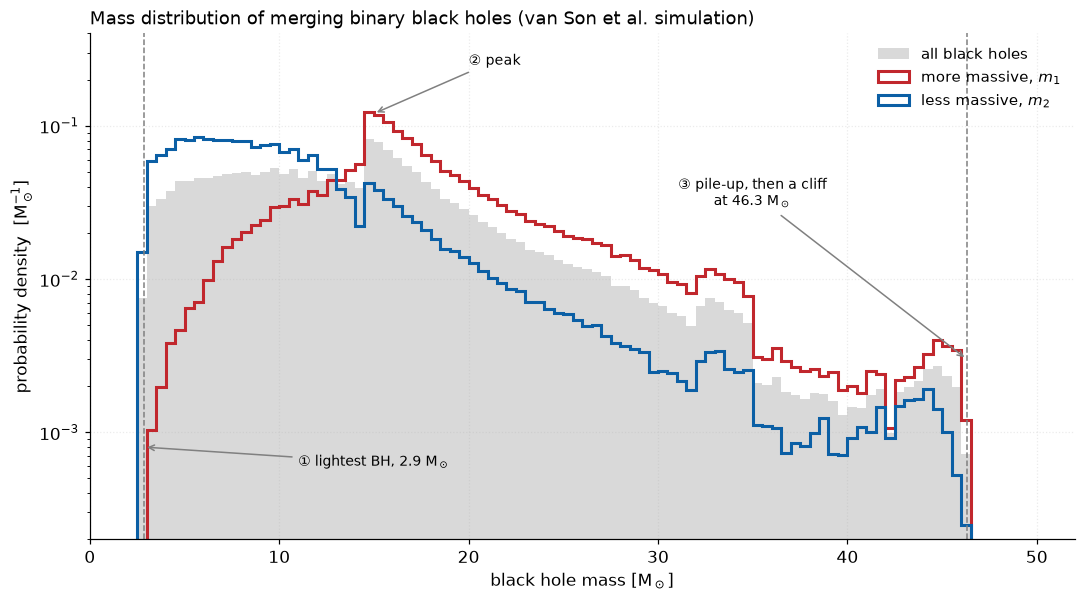

lightest black hole in the sample :   2.87 Msun
heaviest below the gap            :  46.30 Msun
weighted median of m1             :  16.60 Msun
weighted median of m2             :   9.46 Msun


In [7]:
# Part 3.2: The mass distribution

bins = np.arange(0, 52, 0.5)
all_masses = np.concatenate([bbh.m1.values, bbh.m2.values])
all_weights = np.concatenate([bbh.w.values, bbh.w.values])

fig, ax = plt.subplots(figsize=(10, 5.6))

ax.hist(all_masses, bins=bins, weights=all_weights, density=True,
        histtype="stepfilled", color="0.85", edgecolor="none", label="all black holes")
ax.hist(bbh.m1, bins=bins, weights=bbh.w, density=True,
        histtype="step", lw=2, color=C1, label=r"more massive, $m_1$")
ax.hist(bbh.m2, bins=bins, weights=bbh.w, density=True,
        histtype="step", lw=2, color=C2, label=r"less massive, $m_2$")

ax.set_yscale("log")
ax.set_xlim(0, 52)
ax.set_ylim(2e-4, 0.4)   # clip the very lowest-density bins so the shape is readable
ax.set_xlabel(r"black hole mass [M$_\odot$]")
ax.set_ylabel(r"probability density  [M$_\odot^{-1}$]")
ax.set_title("Mass distribution of merging binary black holes (van Son et al. simulation)",
             loc="left", fontsize=12)
ax.legend(loc="upper right", fontsize=10)

# --- annotate the features we are about to discuss ------------------------------
m_min = all_masses.min()
m_max_below_gap = all_masses[all_masses < 100].max()
ax.axvline(m_min, color="grey", lw=1, ls="--")
ax.axvline(m_max_below_gap, color="grey", lw=1, ls="--")
ax.annotate(f"① lightest BH, {m_min:.1f} M$_\\odot$", xy=(m_min, 8e-4), xytext=(11, 6e-4),
            fontsize=9, ha="left", arrowprops=dict(arrowstyle="->", color="grey", lw=1))
ax.annotate("② peak", xy=(15, 0.12), xytext=(20, 0.25),
            fontsize=9, ha="left", arrowprops=dict(arrowstyle="->", color="grey", lw=1))
ax.annotate(f"③ pile-up, then a cliff\nat {m_max_below_gap:.1f} M$_\\odot$",
            xy=(m_max_below_gap, 3e-3), xytext=(35, 3e-2), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color="grey", lw=1))

plt.tight_layout()
plt.show()

print(f"lightest black hole in the sample : {m_min:6.2f} Msun")
print(f"heaviest below the gap            : {m_max_below_gap:6.2f} Msun")
print(f"weighted median of m1             : {weighted_median(bbh.m1, bbh.w):6.2f} Msun")
print(f"weighted median of m2             : {weighted_median(bbh.m2, bbh.w):6.2f} Msun")

In [8]:
# Part 3.3- The pair-instability supernova mass gap

edges = np.arange(0, 200, 2.0)
counts, _ = np.histogram(all_masses, bins=edges, weights=all_weights)

occupied = edges[:-1][counts > 0]
print("Mass bins (2 Msun wide) that contain at least one black hole:")
print(f"   from {occupied.min():.0f} to {occupied[occupied < 100].max() + 2:.0f} Msun ... "
      f"then NOTHING ... then {occupied[occupied > 100].min():.0f} to {occupied.max() + 2:.0f} Msun")

gap = (all_masses > 50) & (all_masses < 120)
print(f"\nBlack holes with 50 < M < 120 Msun: {gap.sum()}  (weighted: {all_weights[gap].sum():.1f})")

above = all_masses > 120
print(f"Black holes above 120 Msun        : {above.sum()}  "
      f"(weighted: {all_weights[above].sum():.2f}, i.e. "
      f"{100*all_weights[above].sum()/all_weights.sum():.4f}% of all black holes)")
print(f"   their masses span {all_masses[above].min():.0f} - {all_masses[above].max():.0f} Msun")

Mass bins (2 Msun wide) that contain at least one black hole:
   from 2 to 48 Msun ... then NOTHING ... then 134 to 142 Msun

Black holes with 50 < M < 120 Msun: 0  (weighted: 0.0)
Black holes above 120 Msun        : 19  (weighted: 0.38, i.e. 0.0013% of all black holes)
   their masses span 135 - 141 Msun


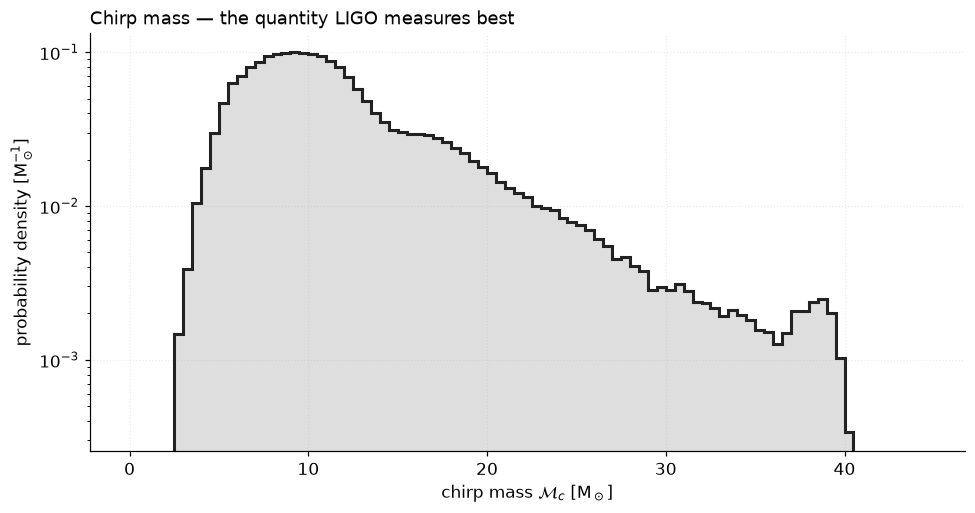

In [9]:
# Part 3.4: The Chirp mass distribution

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(bbh.Mchirp, bins=np.arange(0, 45, 0.5), weights=bbh.w, density=True,
        histtype="stepfilled", color=CSYS, alpha=0.15)
ax.hist(bbh.Mchirp, bins=np.arange(0, 45, 0.5), weights=bbh.w, density=True,
        histtype="step", lw=2, color=CSYS)
ax.set_yscale("log")
ax.set_xlabel(r"chirp mass $\mathcal{M}_c$ [M$_\odot$]")
ax.set_ylabel(r"probability density [M$_\odot^{-1}$]")
ax.set_title("Chirp mass — the quantity LIGO measures best", loc="left", fontsize=12)
plt.tight_layout()
plt.show()

# Part 4: The 2D mass distribution: $m_1$ vs $m_2$

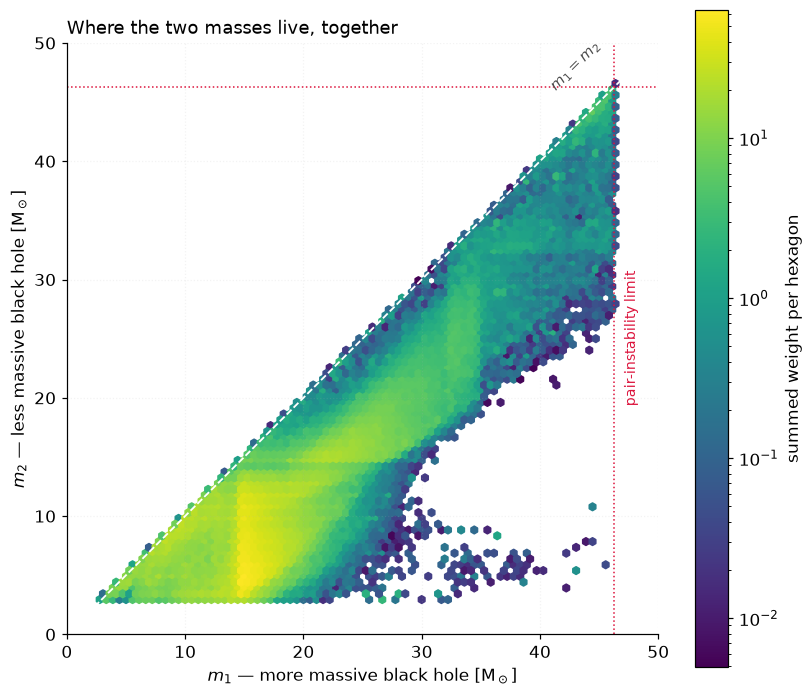

In [10]:
fig, ax = plt.subplots(figsize=(7.6, 6.6))

hb = ax.hexbin(bbh.m1, bbh.m2, C=bbh.w, reduce_C_function=np.sum,
               gridsize=90, extent=(0, 50, 0, 50), mincnt=1,
               norm=LogNorm(), cmap="viridis")
cb = fig.colorbar(hb, ax=ax)
cb.set_label("summed weight per hexagon")

ax.plot([0, 50], [0, 50], color="white", lw=1.2, ls="--")
ax.text(43, 46, r"$m_1 = m_2$", color="0.3", fontsize=10, ha="center", rotation=45)

# mark the pair-instability limit on both axes. NOTE: we use the heaviest BH *below*
# the gap, not bbh.m1.max() -- that would pick up the rare ~140 Msun above-gap systems.
m_lim = bbh.m1[bbh.m1 < 100].max()
ax.axvline(m_lim, color="crimson", lw=1, ls=":")
ax.axhline(m_lim, color="crimson", lw=1, ls=":")
ax.text(m_lim + 0.8, 25, "pair-instability limit", color="crimson", fontsize=9,
        rotation=90, va="center")

ax.set_xlabel(r"$m_1$ — more massive black hole [M$_\odot$]")
ax.set_ylabel(r"$m_2$ — less massive black hole [M$_\odot$]")
ax.set_title("Where the two masses live, together", loc="left", fontsize=12)
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)
ax.set_aspect("equal")
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

# Part 5: Seperation vs mass ratio- finding the islands

In [11]:
# Part 5.1: A missing columns, and how to get it back

# SI constants -- no external dependencies needed
G_SI  = 6.67430e-11        # m^3 kg^-1 s^-2
C_SI  = 2.99792458e8       # m s^-1
MSUN  = 1.98892e30         # kg
RSUN  = 6.957e8            # m
MYR   = 3.15576e13         # s
GYR   = 3.15576e16         # s


def separation_from_merger_time(t_merge_Myr, m1_msun, m2_msun):
    '''Invert Peters (1964) for a circular orbit: given the time to merge, return a in Rsun.'''
    t  = np.asarray(t_merge_Myr) * MYR
    m1 = np.asarray(m1_msun) * MSUN
    m2 = np.asarray(m2_msun) * MSUN
    a_metres = (256.0 / 5.0 * G_SI**3 * m1 * m2 * (m1 + m2) * t / C_SI**5) ** 0.25
    return a_metres / RSUN


def merger_time_from_separation(a_rsun, m1_msun, m2_msun):
    '''The forward direction, for the sanity check below. Returns Myr.'''
    a  = np.asarray(a_rsun) * RSUN
    m1 = np.asarray(m1_msun) * MSUN
    m2 = np.asarray(m2_msun) * MSUN
    t_sec = 5.0 / 256.0 * C_SI**5 * a**4 / (G_SI**3 * m1 * m2 * (m1 + m2))
    return t_sec / MYR


bbh["a_Rsun"] = separation_from_merger_time(bbh.t_coal_Myr, bbh.m1, bbh.m2)
bbh["log_a"]  = np.log10(bbh.a_Rsun)

# --- sanity check: does the round trip give back what we started with? ----------
t_back = merger_time_from_separation(bbh.a_Rsun, bbh.m1, bbh.m2)
print(f"round-trip check, max relative error: "
      f"{np.max(np.abs(t_back - bbh.t_coal_Myr) / bbh.t_coal_Myr):.2e}   (should be ~0)")

print(f"\nreconstructed separations [Rsun]:")
for p in [0, 1, 25, 50, 75, 99, 100]:
    print(f"   {p:3d}th percentile : {np.percentile(bbh.a_Rsun, p):9.4f}")
print(f"\nFor scale: the Sun's radius is 1 Rsun, and the Earth-Sun distance is 215 Rsun.")
print(f"({(bbh.a_Rsun < 1).sum()} systems come out below 1 Rsun -- these are the rare binaries "
      f"that merge essentially\n instantly, and we will simply leave them off the left edge of "
      f"the plots below.)")

round-trip check, max relative error: 1.55e-15   (should be ~0)

reconstructed separations [Rsun]:
     0th percentile :    0.0044
     1th percentile :    3.1121
    25th percentile :    5.6602
    50th percentile :    8.7385
    75th percentile :   15.2947
    99th percentile :   41.8341
   100th percentile :   64.0785

For scale: the Sun's radius is 1 Rsun, and the Earth-Sun distance is 215 Rsun.
(280 systems come out below 1 Rsun -- these are the rare binaries that merge essentially
 instantly, and we will simply leave them off the left edge of the plots below.)


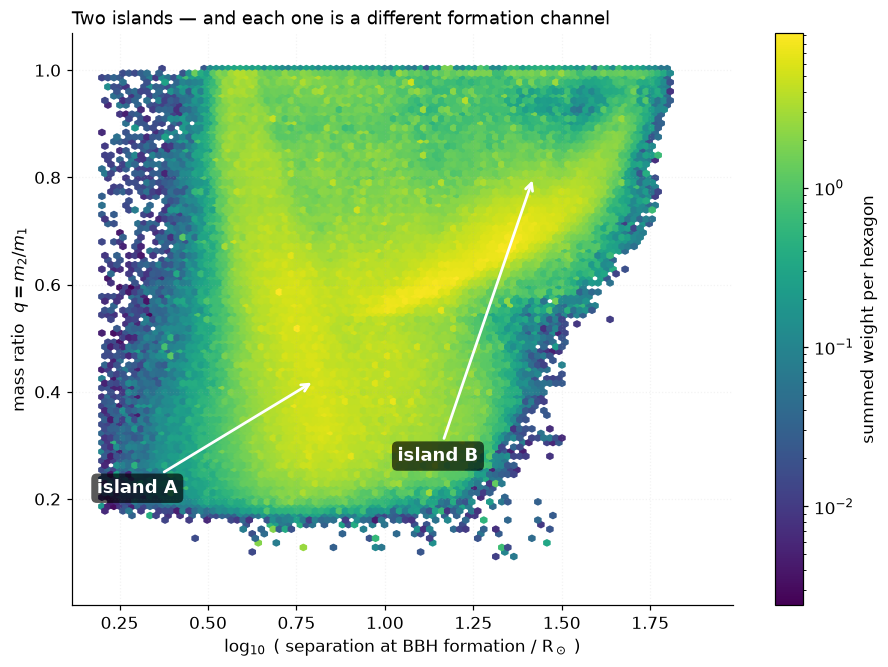

In [12]:
# Part 5.2: The plot: $log_{10}a$ vs $q$

fig, ax = plt.subplots(figsize=(8.4, 6.2))

hb = ax.hexbin(bbh.log_a, bbh.q, C=bbh.w, reduce_C_function=np.sum,
               gridsize=100, extent=(0.2, 1.9, 0.05, 1.02), mincnt=1,
               norm=LogNorm(), cmap="viridis")
cb = fig.colorbar(hb, ax=ax)
cb.set_label("summed weight per hexagon")

# point out the two concentrations discussed in the text
for xy, label, xytext in [((0.80, 0.42), "island A", (0.30, 0.22)),
                          ((1.42, 0.80), "island B", (1.15, 0.28))]:
    ax.annotate(label, xy=xy, xytext=xytext, fontsize=12, color="white", weight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="none", alpha=0.65),
                arrowprops=dict(arrowstyle="->", color="white", lw=1.8))

ax.set_xlabel(r"$\log_{10}$ ( separation at BBH formation / R$_\odot$ )")
ax.set_ylabel(r"mass ratio  $q = m_2/m_1$")
ax.set_title("Two islands — and each one is a different formation channel", loc="left", fontsize=12)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

In [13]:
# CE_Event_Counter: how many common-envelope events the binary went through.
print(bbh.groupby("n_CE").agg(
    rows=("n_CE", "size"),
    weighted=("w", "sum"),
).assign(weighted_pct=lambda d: 100 * d.weighted / d.weighted.sum()).round(1))

ce_mask  = bbh.n_CE >= 1      # went through at least one common envelope
smt_mask = bbh.n_CE == 0      # never had one: only stable mass transfer

         rows  weighted  weighted_pct
n_CE                                 
0      452787    4106.4          27.5
1     1180083   10520.0          70.6
2        7680     284.7           1.9


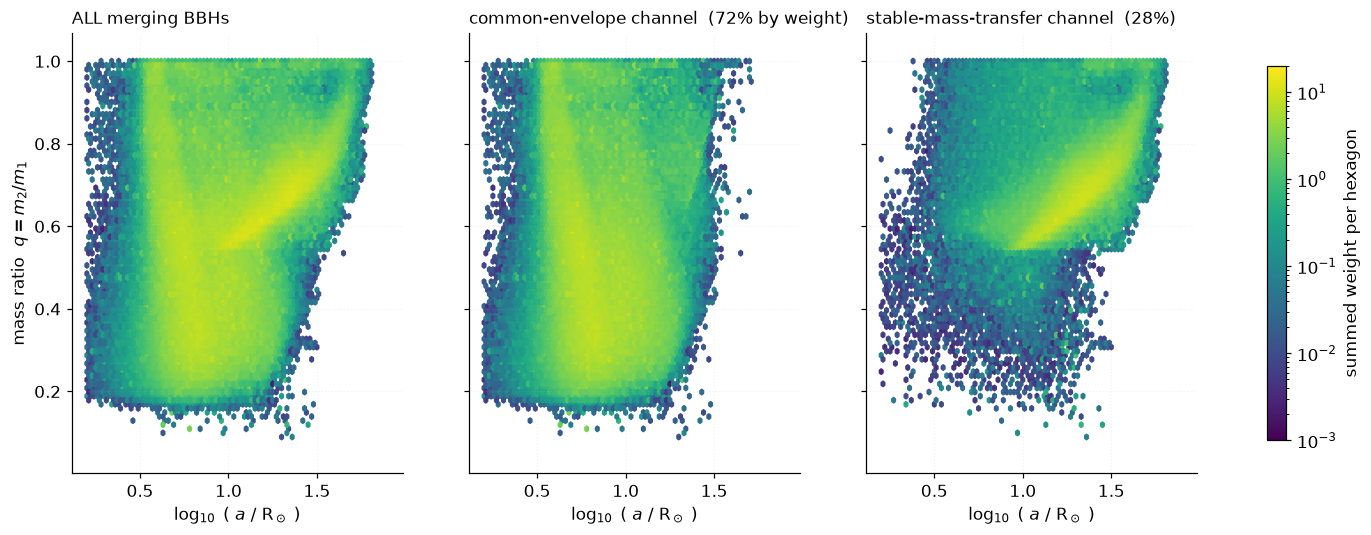

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), sharex=True, sharey=True)

# The SAME colour map and the SAME normalisation in all three panels, so that equal
# colour means equal weight and the panels can honestly be compared by eye.
panels = [
    (bbh, "ALL merging BBHs"),
    (bbh[ce_mask],  f"common-envelope channel  ({100*bbh.w[ce_mask].sum()/bbh.w.sum():.0f}% by weight)"),
    (bbh[smt_mask], f"stable-mass-transfer channel  ({100*bbh.w[smt_mask].sum()/bbh.w.sum():.0f}%)"),
]

for ax, (d, title) in zip(axes, panels):
    hb = ax.hexbin(d.log_a, d.q, C=d.w, reduce_C_function=np.sum,
                   gridsize=85, extent=(0.2, 1.9, 0.05, 1.02), mincnt=1,
                   norm=LogNorm(vmin=1e-3, vmax=20), cmap="viridis")
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel(r"$\log_{10}$ ( $a$ / R$_\odot$ )")
    ax.grid(alpha=0.15)

axes[0].set_ylabel(r"mass ratio  $q = m_2/m_1$")
fig.colorbar(hb, ax=axes, shrink=0.85, label="summed weight per hexagon")
plt.show()

In [15]:
# weighted_median() was defined back in section 1.2 -- reusing it here
print(f"{'channel':28s} {'weight %':>9s} {'med m1':>8s} {'med q':>7s} "
      f"{'med a [Rsun]':>13s} {'med delay [Myr]':>16s}")
print("-" * 86)
for name, m in [("common envelope", ce_mask), ("stable mass transfer", smt_mask)]:
    d = bbh[m]
    print(f"{name:28s} {100*d.w.sum()/bbh.w.sum():8.1f}% "
          f"{weighted_median(d.m1, d.w):8.1f} {weighted_median(d.q, d.w):7.2f} "
          f"{weighted_median(d.a_Rsun, d.w):13.1f} "
          f"{weighted_median(d.t_form_Myr + d.t_coal_Myr, d.w):16.0f}")

print()
heavy, light = bbh.m1 > 30, bbh.m1 < 30
print(f"Of black holes with m1 > 30 Msun, "
      f"{100*bbh.w[smt_mask & heavy].sum()/bbh.w[heavy].sum():.0f}% come from stable mass transfer.")
print(f"Of black holes with m1 < 30 Msun, "
      f"{100*bbh.w[ce_mask & light].sum()/bbh.w[light].sum():.0f}% come from the common-envelope channel.")

channel                       weight %   med m1   med q  med a [Rsun]  med delay [Myr]
--------------------------------------------------------------------------------------
common envelope                  72.5%     15.7    0.53           7.1              175
stable mass transfer             27.5%     24.4    0.70          19.7             1856

Of black holes with m1 > 30 Msun, 79% come from stable mass transfer.
Of black holes with m1 < 30 Msun, 77% come from the common-envelope channel.


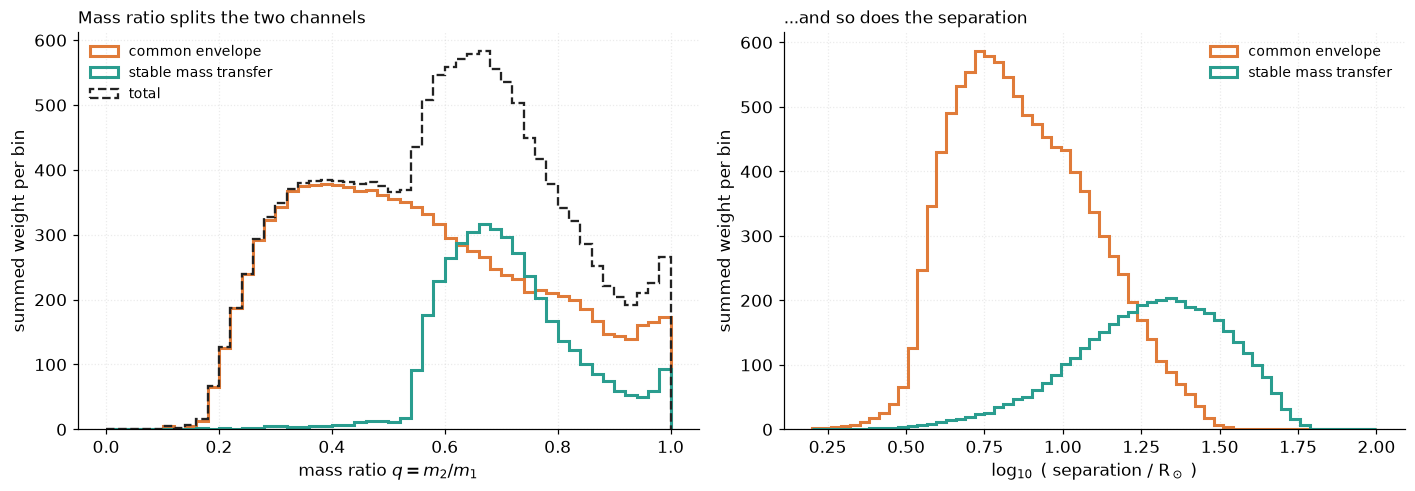

In [16]:
# Part 5.3L The same split, seen in the mass ratio alone

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

qbins = np.linspace(0, 1, 51)
for name, m, col in [("common envelope", ce_mask, C_CE),
                     ("stable mass transfer", smt_mask, C_SMT)]:
    axes[0].hist(bbh.q[m], bins=qbins, weights=bbh.w[m], histtype="step", lw=2,
                 color=col, label=name)
axes[0].hist(bbh.q, bins=qbins, weights=bbh.w, histtype="step", lw=1.5, color=CSYS,
             ls="--", label="total")
axes[0].set_xlabel(r"mass ratio $q = m_2/m_1$")
axes[0].set_ylabel("summed weight per bin")
axes[0].set_title("Mass ratio splits the two channels", loc="left", fontsize=11)
axes[0].legend(fontsize=9)

abins = np.linspace(0.2, 2.0, 60)
for name, m, col in [("common envelope", ce_mask, C_CE),
                     ("stable mass transfer", smt_mask, C_SMT)]:
    axes[1].hist(bbh.log_a[m], bins=abins, weights=bbh.w[m], histtype="step", lw=2,
                 color=col, label=name)
axes[1].set_xlabel(r"$\log_{10}$ ( separation / R$_\odot$ )")
axes[1].set_ylabel("summed weight per bin")
axes[1].set_title("...and so does the separation", loc="left", fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Part 6: Bonus- metallicity, the master variable

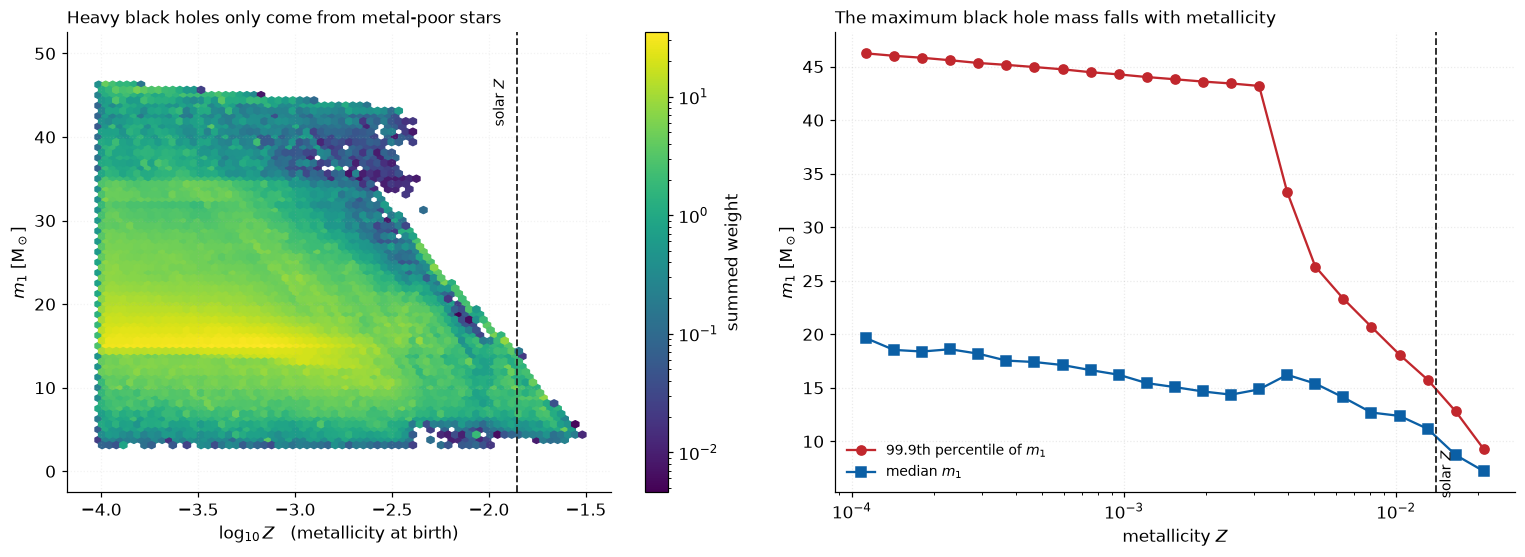

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# --- left: the full 2D density ---------------------------------------------------
ax = axes[0]
hb = ax.hexbin(np.log10(bbh.Z), bbh.m1, C=bbh.w, reduce_C_function=np.sum,
               gridsize=70, extent=(-4.05, -1.5, 0, 50), mincnt=1,
               norm=LogNorm(), cmap="viridis")
fig.colorbar(hb, ax=ax, label="summed weight")
ax.axvline(np.log10(0.014), color=CSYS, lw=1.2, ls="--")
ax.text(np.log10(0.014) - 0.05, 47, "solar $Z$", rotation=90, fontsize=9, ha="right", va="top")
ax.set_xlabel(r"$\log_{10} Z$   (metallicity at birth)")
ax.set_ylabel(r"$m_1$ [M$_\odot$]")
ax.set_title("Heavy black holes only come from metal-poor stars", loc="left", fontsize=11)
ax.grid(alpha=0.15)

# --- right: the maximum BH mass per metallicity bin ------------------------------
ax = axes[1]
zbins = np.logspace(-4, np.log10(0.03), 25)
zc, mmax, mmed = [], [], []
for lo, hi in zip(zbins[:-1], zbins[1:]):
    m = (bbh.Z >= lo) & (bbh.Z < hi) & (bbh.w > 0.01)   # drop the very lowest-weight outliers
    if m.sum() > 100:
        zc.append(np.sqrt(lo * hi))
        mmax.append(np.percentile(bbh.m1[m], 99.9))
        mmed.append(weighted_median(bbh.m1[m], bbh.w[m]))

ax.plot(zc, mmax, "o-", color=C1, label="99.9th percentile of $m_1$")
ax.plot(zc, mmed, "s-", color=C2, label="median $m_1$")
ax.set_xscale("log")
ax.axvline(0.014, color=CSYS, lw=1.2, ls="--")
ax.text(0.0145, 5, "solar $Z$", rotation=90, fontsize=9)
ax.set_xlabel(r"metallicity $Z$")
ax.set_ylabel(r"$m_1$ [M$_\odot$]")
ax.set_title("The maximum black hole mass falls with metallicity", loc="left", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()